In [1]:
!pip install pandas scikit-learn matplotlib seaborn


In [9]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\Asus\OneDrive\Desktop\Documents\normalized_news.csv")  # Make sure this file is in the same folder
print(df.head())

df.head()

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  text_length  normalized_length  
0  December 31, 2017      0          495           0.060848  
1  December 31, 2017      0          305           0.037492  
2  December 30, 2017      0          580           0.071297  
3  December 29, 2017      0   

,title,text,subject,date,label,text_length,normalized_length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,495,0.060848
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,305,0.037492
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,580,0.071297
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,444,0.054579
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,420,0.051629


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=5000)  # Optional: limit to top 5000 words
X = vectorizer.fit_transform(df['text'])

# Convert to DataFrame
word_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())


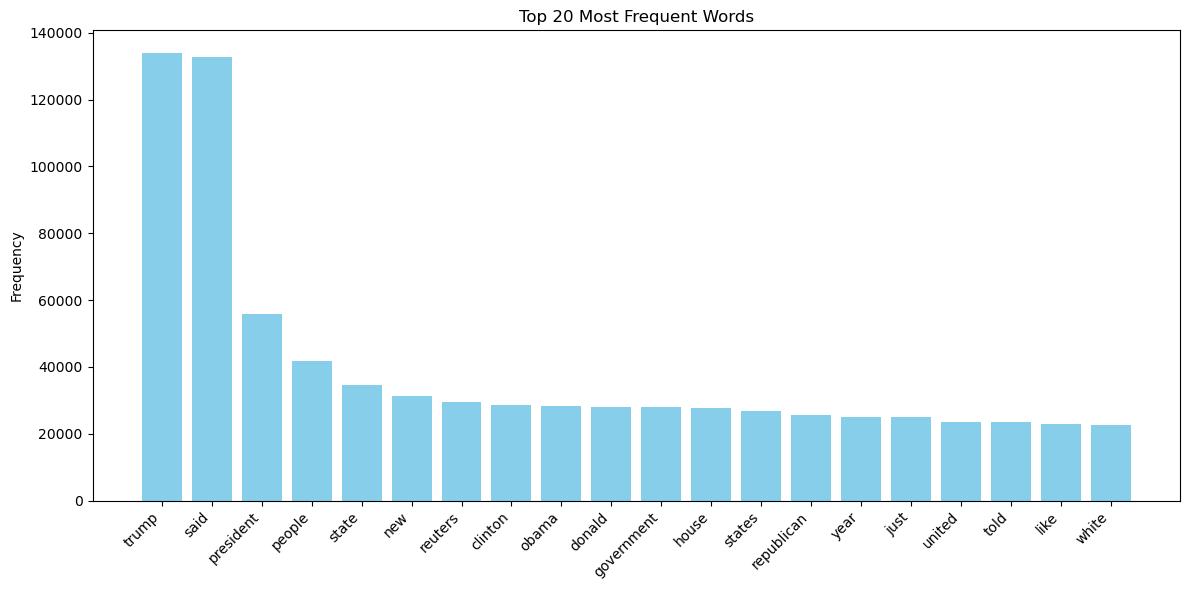

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
import numpy as np

# Combine default and custom stop words
custom_stop_words = text.ENGLISH_STOP_WORDS.union(['system', 'etc', 'also'])
stop_words_list = list(custom_stop_words)

# Initialize CountVectorizer
vectorizer = CountVectorizer(stop_words=stop_words_list)

# Fit-transform text data into sparse matrix
X = vectorizer.fit_transform(df['text'])

# Get feature (word) names
feature_names = vectorizer.get_feature_names_out()

# Sum total word frequencies across all documents (sparse, efficient)
word_counts = np.asarray(X.sum(axis=0)).flatten()

# Create a word-frequency mapping
word_freq_df = pd.DataFrame({'word': feature_names, 'frequency': word_counts})
word_freq_df = word_freq_df.sort_values(by='frequency', ascending=False)

# Plot Top 20 Most Frequent Words
top_words = word_freq_df.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_words['word'], top_words['frequency'], color='skyblue')
plt.title('Top 20 Most Frequent Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Save word frequency matrix (sparse)
# Optional: Save top 5000 columns only to keep file manageable
top_k = 5000
top_indices = np.argsort(word_counts)[-top_k:]

X_top = X[:, top_indices]  # still sparse
selected_features = feature_names[top_indices]

# Save to CSV in chunks
df_top = pd.DataFrame.sparse.from_spmatrix(X_top, columns=selected_features)
df_top.to_csv('word_matrix.csv', index=False)


In [44]:
word_df.to_csv("word_matrix.csv", index=False)
print("Word matrix with counts saved as word_matrix.csv")


Word matrix with counts saved as word_matrix.csv
